In [ ]:
# import Pkg
# Pkg.develop(path=pwd())

In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Documents/RVSDDP`


In [1]:
using Revise
using RVSDDP
using Random
using Plots
using Gurobi
using Statistics
# using HiGHS
# optimizer = () -> HiGHS.Optimizer()
using Gurobi
const GRB_ENV = Gurobi.Env()
optimizer=() -> Gurobi.Optimizer(GRB_ENV)

Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


#15 (generic function with 1 method)

In [2]:
discount_factor=0.99
graph=RVSDDP.InfiniteLinearGraph(1);

In [3]:
function subproblem_builder(subproblem::Model, node::Int, discount_factor::Float64)
    # State variables
    N=1
    @variable(subproblem, 0 <= volume[1:N] <= 200, RVSDDP.State, initial_value = 50)
    # Control variables
    @variables(subproblem, begin
        thermal_generation[1:4] >= 0
        thermal_generation_tot >= 0
        hydro_generation[1:N] >= 0
        hydro_spill[1:N] >= 0
        deficit >= 0
    end)
    # Random variables
    @variable(subproblem, inflow)
    Ω = [20.0, 80.0]
    # Ω = [40.0]
    P = [1 / length(Ω) for _ in Ω]
    # Ω = [70.0]
    # P = [1.0]
    RVSDDP.parameterize(subproblem, Ω, P) do ω
        return JuMP.fix(inflow, ω)
    end

    capa_th = [10 15 10 5] 
    c_th = [1 2 5 10]
    # Transition function and constraints
    @constraints(
        subproblem,
        begin
            [i in 1:N], volume[i].out == volume[i].in - hydro_generation[i] - hydro_spill[i] + inflow
            [i in 1:N], hydro_generation[i] <= 100
            [i in 1:1], thermal_generation[i] <= capa_th[i]
            thermal_generation_tot==sum(thermal_generation[i] for i in 1:4)
            deficit + sum(hydro_generation[i] for i in 1:N) + thermal_generation_tot == 60+0*node
        end
    )
    # Stage-objective
    @stageobjective(subproblem, 1*(50*sum(hydro_spill[i] for i in 1:N) + 50 * deficit+ sum(thermal_generation[i]*c_th[i] for i in 1:4)))
    return subproblem
end

subproblem_builder (generic function with 1 method)

In [16]:
model0 = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model0; parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=300, rollout_limit = i -> 2*i, parallel=parallel), iteration_limit = 50, infinite = true, shift_function=RVSDDP.no_shift); 

In [17]:
model1 = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel=1
Cuts1=RVSDDP.train(model1; parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=300, rollout_limit = i -> 2*i, parallel=parallel), iteration_limit = 50, infinite = true, shift_function=RVSDDP.shift_update_random_forward); 

In [10]:
Random.seed!(12)
N=1000
TimeHorizon = 100
simulations= RVSDDP.simulate(
           model0,
           N;
           sampling_scheme = RVSDDP.InSampleMonteCarlo(max_depth=TimeHorizon),
       )
oos = [sum((discount_factor^(t-1))*simulations[k][t][:stage_objective] for t in 1:TimeHorizon)+simulations[k][TimeHorizon][:cost_end_of_horizon] for k in 1:N];

In [16]:
using Statistics
using Distributions

function ic95(L::Vector{Float64})
    n = length(L)
    m = mean(L)
    s = std(L)                  # écart-type échantillon
    tcrit = quantile(TDist(n-1), 0.975)
    println((tcrit, s, sqrt(n)))
    marge = tcrit * s / sqrt(n)
    println(marge)
    return (m - marge, m, m + marge)
end

ic_oos = ic95(oos)
ic_oos, model0.approx_value[end], model1.approx_value[end]

(1.9623414611334569, 781.5643657479629, 31.622776601683793)
48.49973102520155


((1685.5463685675024, 1734.046099592704, 1782.5458306179055), 1737.125045032315, 1736.155865409724)

In [14]:
RVSDDP.compute_hat_delta(model0, 1, 50)

39.03959846347785

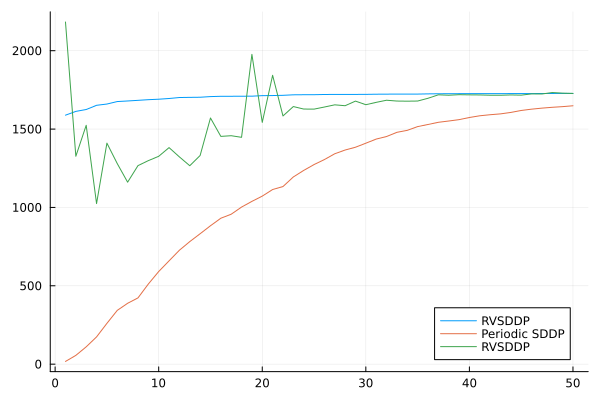

In [ ]:
p=plot(model1.approx_value .+ RVSDDP.compute_hat_delta(model1, 1, 50), label="RVSDDP")
plot!(model0.approx_value, label="Periodic SDDP")
plot!(model1.approx_value + [RVSDDP.compute_hat_delta(model1, 1, iter) for iter in 1:50], label="RVSDDP")

# plot!(model0.approx_value + [RVSDDP.compute_hat_delta(model0, 1, iter) for iter in 1:100], label="RVSDDP")
# ic_oos = ic95(oos)
# hline!(p, [ic_oos[2]], label="OOS 95% CI lower", linestyle=:dash, color=:red, linewidth=2)